In [ ]:
# Install the libraries required for VideoMAE training

!pip install -q transformers accelerate opencv-python scikit-learn

In [ ]:
# Connect Google Drive for permanent dataset and model storage

from google.colab import drive
import os

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/cricket_videomae"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Google Drive connected successfully ✅")
print("Save folder:", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected successfully ✅
Save folder: /content/drive/MyDrive/cricket_videomae


In [ ]:
# Import libraries and check the available training device

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

print("Imports successful ✅")

print("\nPyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Imports successful ✅

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda


In [ ]:
# Set the cricket dataset path and inspect its class folders

DATASET_DIR = "/content/drive/MyDrive/crickshot10/crickshot10"

print("Dataset path:", DATASET_DIR)
print("Dataset exists:", os.path.exists(DATASET_DIR))

print("\nClasses found:")
print(os.listdir(DATASET_DIR))

Dataset path: /content/drive/MyDrive/crickshot10/crickshot10
Dataset exists: True

Classes found:
['square_cut', 'hook', 'late_cut', 'pull', 'defense', 'cover', 'straight', 'sweep', 'lofted', 'flick']


In [ ]:
# Count the number of video clips available in each cricket shot class

class_counts = {}

for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = os.path.join(DATASET_DIR, class_name)

    if os.path.isdir(class_path):
        videos = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))
        ]
        class_counts[class_name] = len(videos)

print("Video count per class:")
for class_name, count in class_counts.items():
    print(f"{class_name:15s}: {count}")

print("\nTotal videos:", sum(class_counts.values()))

Video count per class:
cover          : 178
defense        : 181
flick          : 171
hook           : 171
late_cut       : 172
lofted         : 189
pull           : 169
square_cut     : 181
straight       : 183
sweep          : 186

Total videos: 1781


In [ ]:
# Create labels and split the cricket videos into train, validation, and test sets

class_names = sorted(class_counts.keys())

label2id = {
    name: i
    for i, name in enumerate(class_names)
}

id2label = {
    i: name
    for name, i in label2id.items()
}

video_paths = []
labels = []

for class_name in class_names:
    class_path = os.path.join(DATASET_DIR, class_name)

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
            video_paths.append(
                os.path.join(class_path, filename)
            )
            labels.append(label2id[class_name])

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Dataset split completed ✅")
print(f"Total videos:      {len(video_paths)}")
print(f"Training videos:   {len(train_paths)}")
print(f"Validation videos: {len(val_paths)}")
print(f"Test videos:       {len(test_paths)}")

print("\nClasses:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Dataset split completed ✅
Total videos:      1781
Training videos:   1246
Validation videos: 267
Test videos:       268

Classes:
0: cover
1: defense
2: flick
3: hook
4: late_cut
5: lofted
6: pull
7: square_cut
8: straight
9: sweep


In [ ]:
# Set the configuration used for VideoMAE preprocessing and training

EPOCHS = 5

BATCH_SIZE = 4
NUM_FRAMES = 16
IMAGE_SIZE = 224

GRADIENT_ACCUMULATION_STEPS = 2

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01

print("Training configuration ready ✅")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Frames per video: {NUM_FRAMES}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Gradient accumulation: {GRADIENT_ACCUMULATION_STEPS}")

Training configuration ready ✅
Epochs: 5
Batch size: 4
Frames per video: 16
Image size: 224x224
Learning rate: 1e-05
Gradient accumulation: 2


In [ ]:
# Load the pretrained VideoMAE-Small model and adapt it to 10 cricket classes

MODEL_NAME = "MCG-NJU/videomae-small-finetuned-kinetics"

processor = VideoMAEImageProcessor.from_pretrained(
    MODEL_NAME
)

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(class_names),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

model = model.to(device)

print("Pretrained VideoMAE-Small loaded successfully ✅")
print("Model:", MODEL_NAME)
print("Number of classes:", len(class_names))
print("Device:", device)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

NameError: name 'label2id' is not defined

In [ ]:
# Create the dataset class that converts cricket videos into VideoMAE inputs

class CricketVideoDataset(Dataset):

    def __init__(self, video_paths, labels, processor, num_frames=16):
        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, index):

        video_path = self.video_paths[index]
        label = self.labels[index]

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames <= 0:
            cap.release()
            raise RuntimeError(
                f"Could not read video: {video_path}"
            )

        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_index in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(frame_index)
            )

            success, frame = cap.read()

            if success:
                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )
                frames.append(frame)

        cap.release()

        while len(frames) < self.num_frames:
            frames.append(frames[-1].copy())

        frames = frames[:self.num_frames]

        inputs = self.processor(
            frames,
            return_tensors="pt"
        )

        pixel_values = inputs["pixel_values"].squeeze(0)

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(
                label,
                dtype=torch.long
            )
        }


print("Dataset class created successfully ✅")

Dataset class created successfully ✅


In [ ]:
# Create DataLoaders for training, validation, and testing

train_dataset = CricketVideoDataset(
    train_paths,
    train_labels,
    processor,
    NUM_FRAMES
)

val_dataset = CricketVideoDataset(
    val_paths,
    val_labels,
    processor,
    NUM_FRAMES
)

test_dataset = CricketVideoDataset(
    test_paths,
    test_labels,
    processor,
    NUM_FRAMES
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully ✅")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created successfully ✅
Train batches: 312
Validation batches: 67
Test batches: 67


In [ ]:
# Check one batch to verify the video preprocessing pipeline

batch = next(iter(train_loader))

print("Batch loaded successfully ✅")
print("Pixel values shape:", batch["pixel_values"].shape)
print("Labels shape:", batch["labels"].shape)
print("Labels:", batch["labels"].tolist())
print("Pixel value dtype:", batch["pixel_values"].dtype)

Batch loaded successfully ✅
Pixel values shape: torch.Size([4, 16, 3, 224, 224])
Labels shape: torch.Size([4])
Labels: [8, 2, 2, 4]
Pixel value dtype: torch.float32


In [ ]:
# Set up the optimizer, mixed precision, and permanent checkpoint location

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scaler = torch.amp.GradScaler("cuda")

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_cricket_videomae.pt"
)

print("Training setup ready ✅")
print("Optimizer: AdamW")
print("Mixed precision: enabled")
print("Checkpoint:", BEST_MODEL_PATH)

Training setup ready ✅
Optimizer: AdamW
Mixed precision: enabled
Checkpoint: /content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt


In [ ]:
# Train VideoMAE for 5 epochs and save the best checkpoint to Google Drive

import time

best_val_accuracy = 0.0
best_epoch = 0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(EPOCHS):

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 60)

    start_time = time.time()

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):

        pixel_values = batch["pixel_values"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast("cuda"):

            outputs = model(
                pixel_values=pixel_values,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            scaled_loss = (
                loss / GRADIENT_ACCUMULATION_STEPS
            )

        scaler.scale(scaled_loss).backward()

        if (
            (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0
            or (step + 1) == len(train_loader)
        ):

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad(set_to_none=True)

        train_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

        if (step + 1) % 50 == 0:

            current_accuracy = (
                train_correct / train_total
            )

            print(
                f"Step {step + 1}/{len(train_loader)} "
                f"| Loss: {loss.item():.4f} "
                f"| Accuracy: {current_accuracy:.4f}"
            )

    train_loss /= len(train_loader)

    train_accuracy = (
        train_correct / train_total
    )

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader:

            pixel_values = batch["pixel_values"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast("cuda"):

                outputs = model(
                    pixel_values=pixel_values,
                    labels=labels
                )

            val_loss += outputs.loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= len(val_loader)

    val_accuracy = (
        val_correct / val_total
    )

    elapsed_time = (
        time.time() - start_time
    ) / 60

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print("\nEpoch Results")
    print("-----------------------")
    print(f"Train Loss:      {train_loss:.4f}")
    print(f"Train Accuracy:  {train_accuracy:.4f}")
    print(f"Val Loss:        {val_loss:.4f}")
    print(f"Val Accuracy:    {val_accuracy:.4f}")
    print(f"Time:            {elapsed_time:.2f} minutes")

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        checkpoint = {
            "epoch": best_epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_accuracy": best_val_accuracy,
            "label2id": label2id,
            "id2label": id2label,
            "class_names": class_names,
            "num_frames": NUM_FRAMES,
            "history": history
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        print("\n🔥 NEW BEST MODEL SAVED!")
        print(f"Best Epoch: {best_epoch}")
        print(
            f"Best Validation Accuracy: "
            f"{best_val_accuracy:.4f}"
        )
        print(f"Checkpoint: {BEST_MODEL_PATH}")

    else:

        print(
            f"\nBest Validation Accuracy so far: "
            f"{best_val_accuracy:.4f}"
        )

print("\n" + "=" * 60)
print("🔥 TRAINING COMPLETE")
print("=" * 60)

print(f"Best Epoch: {best_epoch}")
print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.4f}"
)
print(f"Best model saved at:\n{BEST_MODEL_PATH}")


Epoch 1/5
Step 50/312 | Loss: 2.2686 | Accuracy: 0.1950
Step 100/312 | Loss: 2.2119 | Accuracy: 0.2500
Step 150/312 | Loss: 2.1047 | Accuracy: 0.2850
Step 200/312 | Loss: 1.9119 | Accuracy: 0.3212
Step 250/312 | Loss: 1.6743 | Accuracy: 0.3560
Step 300/312 | Loss: 1.4091 | Accuracy: 0.3825

Epoch Results
-----------------------
Train Loss:      1.9608
Train Accuracy:  0.3892
Val Loss:        1.6430
Val Accuracy:    0.4831
Time:            27.55 minutes

🔥 NEW BEST MODEL SAVED!
Best Epoch: 1
Best Validation Accuracy: 0.4831
Checkpoint: /content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt

Epoch 2/5
Step 50/312 | Loss: 1.7214 | Accuracy: 0.5650
Step 100/312 | Loss: 1.9931 | Accuracy: 0.5800
Step 150/312 | Loss: 1.7930 | Accuracy: 0.6017
Step 200/312 | Loss: 1.3242 | Accuracy: 0.6050
Step 250/312 | Loss: 1.7080 | Accuracy: 0.6070
Step 300/312 | Loss: 1.8772 | Accuracy: 0.6033

Epoch Results
-----------------------
Train Loss:      1.4001
Train Accuracy:  0.6019
Val Loss:     

In [ ]:
# Check whether the best trained model is safely stored in Google Drive

import os

BEST_MODEL_PATH = "/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt"

print("Checkpoint exists:", os.path.exists(BEST_MODEL_PATH))

if os.path.exists(BEST_MODEL_PATH):
    print("Checkpoint size:",
          round(os.path.getsize(BEST_MODEL_PATH) / (1024**2), 2),
          "MB")
    print("Saved checkpoint:", BEST_MODEL_PATH)

Checkpoint exists: False


In [ ]:
# Search Google Drive for any saved VideoMAE checkpoint

from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pt") or file.endswith(".pth"):
            if "cricket" in file.lower() or "videomae" in file.lower():
                print(os.path.join(root, file))

Mounted at /content/drive
/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt


In [ ]:
# Verify the saved checkpoint and recover its training information

import torch
import os

BEST_MODEL_PATH = "/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt"

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu"
)

print("Checkpoint loaded successfully ✅")
print("Saved epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])
print("Classes:", checkpoint["class_names"])
print("Number of classes:", len(checkpoint["class_names"]))

Checkpoint loaded successfully ✅
Saved epoch: 2
Best validation accuracy: 0.5655430711610487
Classes: ['cover', 'defense', 'flick', 'hook', 'late_cut', 'lofted', 'pull', 'square_cut', 'straight', 'sweep']
Number of classes: 10


In [ ]:
# Reconnect the GPU and recreate the pretrained VideoMAE model

import torch
from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("WARNING: GPU is not available")

MODEL_NAME = "MCG-NJU/videomae-small-finetuned-kinetics"

processor = VideoMAEImageProcessor.from_pretrained(
    MODEL_NAME
)

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

print("VideoMAE architecture recreated ✅")

CUDA available: False


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

NameError: name 'label2id' is not defined

In [ ]:
# Download the saved best model to your laptop

from google.colab import files

files.download(
    "/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Import libraries and check the available training device

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

print("Imports successful ✅")

print("\nPyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Imports successful ✅

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

checkpoint_path = "/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt"

print("Checkpoint exists:", __import__("os").path.exists(checkpoint_path))

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda
Checkpoint exists: True


In [ ]:
# ============================================================
# LOAD CHECKPOINT INFORMATION
# ============================================================

import torch
from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

CHECKPOINT_PATH = "/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt"

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu"
)

# Restore class information from checkpoint
class_names = checkpoint["class_names"]
label2id = checkpoint["label2id"]
id2label = checkpoint["id2label"]

print("============================================================")
print("CHECKPOINT INFORMATION RESTORED")
print("============================================================")

print("Saved epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])
print("Classes:", class_names)
print("Number of classes:", len(class_names))

print("label2id:", label2id)
print("id2label:", id2label)

CHECKPOINT INFORMATION RESTORED
Saved epoch: 2
Best validation accuracy: 0.5655430711610487
Classes: ['cover', 'defense', 'flick', 'hook', 'late_cut', 'lofted', 'pull', 'square_cut', 'straight', 'sweep']
Number of classes: 10
label2id: {'cover': 0, 'defense': 1, 'flick': 2, 'hook': 3, 'late_cut': 4, 'lofted': 5, 'pull': 6, 'square_cut': 7, 'straight': 8, 'sweep': 9}
id2label: {0: 'cover', 1: 'defense', 2: 'flick', 3: 'hook', 4: 'late_cut', 5: 'lofted', 6: 'pull', 7: 'square_cut', 8: 'straight', 9: 'sweep'}


In [ ]:
# ============================================================
# LOAD PRETRAINED VIDEOMAE-SMALL FOR 10 CRICKET CLASSES
# ============================================================

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

print("=" * 60)
print("LOADING PRETRAINED VIDEOMAE-SMALL")
print("=" * 60)

# ------------------------------------------------------------
# YOUR 10 CRICKET CLASSES
# ------------------------------------------------------------

class_names = [
    'cover',
    'defense',
    'flick',
    'hook',
    'late_cut',
    'lofted',
    'pull',
    'square_cut',
    'straight',
    'sweep'
]

label2id = {
    name: i
    for i, name in enumerate(class_names)
}

id2label = {
    i: name
    for i, name in enumerate(class_names)
}

print("Classes:", class_names)
print("Number of classes:", len(class_names))


# ------------------------------------------------------------
# PRETRAINED MODEL
# ------------------------------------------------------------

MODEL_NAME = "MCG-NJU/videomae-small-finetuned-kinetics"


# ------------------------------------------------------------
# PROCESSOR
# ------------------------------------------------------------

processor = VideoMAEImageProcessor.from_pretrained(
    MODEL_NAME
)


# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_NAME,

    # Our task has 10 classes
    num_labels=10,

    # IMPORTANT:
    # Replace the original 400-class mapping
    label2id=label2id,
    id2label=id2label,

    # Replace the Kinetics classifier head
    ignore_mismatched_sizes=True
)


# ------------------------------------------------------------
# MOVE TO GPU
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print()
print("=" * 60)
print("VideoMAE-Small loaded successfully ✅")
print("=" * 60)

print("Model:", MODEL_NAME)
print("Number of classes:", model.config.num_labels)
print("Device:", device)

print()
print("Classifier output size:",
      model.classifier.out_features)

print()
print("Label mapping:")
print(model.config.id2label)

print("=" * 60)

LOADING PRETRAINED VIDEOMAE-SMALL
Classes: ['cover', 'defense', 'flick', 'hook', 'late_cut', 'lofted', 'pull', 'square_cut', 'straight', 'sweep']
Number of classes: 10


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `400`.


Loading weights:   0%|          | 0/162 [00:00<?, ?it/s]

[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-small-finetuned-kinetics
Key                                                            | Status     |                                                                                          
---------------------------------------------------------------+------------+------------------------------------------------------------------------------------------
videomae.encoder.layer.{0...11}.attention.attention.v_bias     | UNEXPECTED |                                                                                          
videomae.encoder.layer.{0...11}.attention.attention.q_bias     | UNEXPECTED |                                                                                          
videomae.encoder.layer.{0...11}.attention.attention.value.bias | MISSING    |                                                                                          
videomae.encoder.layer.{0...11}.attention.attention.ke


VideoMAE-Small loaded successfully ✅
Model: MCG-NJU/videomae-small-finetuned-kinetics
Number of classes: 10
Device: cuda

Classifier output size: 10

Label mapping:
{0: 'cover', 1: 'defense', 2: 'flick', 3: 'hook', 4: 'late_cut', 5: 'lofted', 6: 'pull', 7: 'square_cut', 8: 'straight', 9: 'sweep'}


In [ ]:
# ============================================================
# VERIFY VIDEOMAE MODEL BEFORE CONTINUING TRAINING
# ============================================================

print("=" * 60)
print("VERIFYING VIDEOMAE MODEL")
print("=" * 60)

# 1. Check classifier
print("\nClassifier:")
print("Input features :", model.classifier.in_features)
print("Output classes :", model.classifier.out_features)

# 2. Check total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("\nParameters:")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# 3. Check device
print("\nDevice:")
print(next(model.parameters()).device)

# 4. Check class mapping
print("\nLabel mapping:")
print(model.config.id2label)

# 5. Check classifier weights
print("\nClassifier weight statistics:")
print("Mean :", model.classifier.weight.mean().item())
print("Std  :", model.classifier.weight.std().item())

print("\n" + "=" * 60)
print("MODEL VERIFICATION COMPLETE ✅")
print("=" * 60)

VERIFYING VIDEOMAE MODEL

Classifier:
Input features : 384
Output classes : 10

Parameters:
Total parameters     : 21,888,394
Trainable parameters : 21,888,394

Device:
cuda:0

Label mapping:
{0: 'cover', 1: 'defense', 2: 'flick', 3: 'hook', 4: 'late_cut', 5: 'lofted', 6: 'pull', 7: 'square_cut', 8: 'straight', 9: 'sweep'}

Classifier weight statistics:
Mean : 0.00019967588013969362
Std  : 0.01989857666194439

MODEL VERIFICATION COMPLETE ✅


In [ ]:
# ============================================================
# RESTORE EPOCH-2 CHECKPOINT
# PREPARE FOR EPOCH 3 → 5
# ============================================================

import torch

print("=" * 60)
print("RESTORING EPOCH-2 CHECKPOINT")
print("=" * 60)

# ------------------------------------------------------------
# CHECKPOINT PATH
# ------------------------------------------------------------

CHECKPOINT_PATH = (
    "/content/drive/MyDrive/"
    "cricket_videomae/"
    "best_cricket_videomae.pt"
)

print("Checkpoint:", CHECKPOINT_PATH)


# ------------------------------------------------------------
# LOAD CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)


# ------------------------------------------------------------
# RESTORE MODEL WEIGHTS
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Model weights restored ✅")


# ------------------------------------------------------------
# RESTORE CHECKPOINT INFORMATION
# ------------------------------------------------------------

saved_epoch = checkpoint["epoch"]

best_val_accuracy = checkpoint["val_accuracy"]

label2id = checkpoint["label2id"]

id2label = checkpoint["id2label"]

class_names = checkpoint["class_names"]

history = checkpoint.get(
    "history",
    {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
)


# ------------------------------------------------------------
# CREATE OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.01
)


# ------------------------------------------------------------
# RESTORE OPTIMIZER STATE
# ------------------------------------------------------------

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)


# ------------------------------------------------------------
# MOVE OPTIMIZER STATE TO GPU
# ------------------------------------------------------------

for state in optimizer.state.values():

    for key, value in state.items():

        if torch.is_tensor(value):

            state[key] = value.to(device)


# ------------------------------------------------------------
# LOSS FUNCTION
# ------------------------------------------------------------

criterion = torch.nn.CrossEntropyLoss()


# ------------------------------------------------------------
# TRAINING RANGE
# ------------------------------------------------------------

NUM_EPOCHS = 5

START_EPOCH = saved_epoch + 1


# ------------------------------------------------------------
# DISPLAY STATUS
# ------------------------------------------------------------

print()
print("=" * 60)
print("CHECKPOINT RESTORED SUCCESSFULLY")
print("=" * 60)

print("Saved epoch:", saved_epoch)

print(
    "Best validation accuracy:",
    best_val_accuracy
)

print("Starting epoch:", START_EPOCH)

print("Final epoch:", NUM_EPOCHS)

print(
    "Epochs remaining:",
    list(range(START_EPOCH, NUM_EPOCHS + 1))
)

print("Classes:", class_names)

print("Number of classes:", len(class_names))

print("Device:", device)

print("=" * 60)

print()
print("READY FOR EPOCH 3 → 5 🚀")

RESTORING EPOCH-2 CHECKPOINT
Checkpoint: /content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt
Model weights restored ✅

CHECKPOINT RESTORED SUCCESSFULLY
Saved epoch: 2
Best validation accuracy: 0.5655430711610487
Starting epoch: 3
Final epoch: 5
Epochs remaining: [3, 4, 5]
Classes: ['cover', 'defense', 'flick', 'hook', 'late_cut', 'lofted', 'pull', 'square_cut', 'straight', 'sweep']
Number of classes: 10
Device: cuda

READY FOR EPOCH 3 → 5 🚀


In [ ]:
# ============================================================
# REBUILD TRAINING ENVIRONMENT
# THEN RESUME FROM EPOCH 2
# EPOCH 3 → EPOCH 5
# ============================================================

import os
import cv2
import numpy as np
import torch
import time

from google.colab import drive
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from transformers import (
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification
)

# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive", force_remount=True)

SAVE_DIR = "/content/drive/MyDrive/cricket_videomae"

CHECKPOINT_PATH = os.path.join(
    SAVE_DIR,
    "best_cricket_videomae.pt"
)

DATASET_DIR = "/content/drive/MyDrive/crickshot10/crickshot10"

print("=" * 60)
print("REBUILDING VIDEOMAE TRAINING ENVIRONMENT")
print("=" * 60)

print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))


# ============================================================
# 2. DEVICE
# ============================================================

if torch.cuda.is_available():

    device = torch.device("cuda")

else:

    device = torch.device("cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 3. LOAD CHECKPOINT INFORMATION
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu"
)

class_names = checkpoint["class_names"]

label2id = checkpoint["label2id"]

id2label = checkpoint["id2label"]

NUM_FRAMES = checkpoint.get(
    "num_frames",
    16
)

print()
print("Checkpoint information restored")
print("Saved epoch:", checkpoint["epoch"])
print("Best validation accuracy:",
      checkpoint["val_accuracy"])

print("Classes:", class_names)


# ============================================================
# 4. TRAINING CONFIGURATION
# ============================================================

BATCH_SIZE = 4

GRADIENT_ACCUMULATION_STEPS = 2

LEARNING_RATE = 1e-5

WEIGHT_DECAY = 0.01

NUM_EPOCHS = 5

START_EPOCH = checkpoint["epoch"] + 1


# ============================================================
# 5. RECREATE DATASET SPLIT
# ============================================================

class_counts = {}

for class_name in sorted(
    os.listdir(DATASET_DIR)
):

    class_path = os.path.join(
        DATASET_DIR,
        class_name
    )

    if os.path.isdir(class_path):

        videos = [
            f
            for f in os.listdir(class_path)
            if f.lower().endswith(
                (".mp4", ".avi", ".mov", ".mkv")
            )
        ]

        class_counts[class_name] = len(videos)


video_paths = []

labels = []


for class_name in class_names:

    class_path = os.path.join(
        DATASET_DIR,
        class_name
    )

    for filename in os.listdir(class_path):

        if filename.lower().endswith(
            (".mp4", ".avi", ".mov", ".mkv")
        ):

            video_paths.append(
                os.path.join(
                    class_path,
                    filename
                )
            )

            labels.append(
                label2id[class_name]
            )


# EXACT SAME SPLIT AS ORIGINAL NOTEBOOK

train_paths, temp_paths, train_labels, temp_labels = train_test_split(

    video_paths,
    labels,

    test_size=0.30,

    random_state=42,

    stratify=labels
)


val_paths, test_paths, val_labels, test_labels = train_test_split(

    temp_paths,
    temp_labels,

    test_size=0.50,

    random_state=42,

    stratify=temp_labels
)


print()
print("Dataset split recreated ✅")

print("Total videos:", len(video_paths))
print("Training videos:", len(train_paths))
print("Validation videos:", len(val_paths))
print("Test videos:", len(test_paths))


# ============================================================
# 6. LOAD VIDEOMAE PROCESSOR
# ============================================================

MODEL_NAME = (
    "MCG-NJU/videomae-small-finetuned-kinetics"
)

processor = VideoMAEImageProcessor.from_pretrained(
    MODEL_NAME
)


# ============================================================
# 7. DATASET CLASS
# ============================================================

class CricketVideoDataset(Dataset):

    def __init__(
        self,
        video_paths,
        labels,
        processor,
        num_frames=16
    ):

        self.video_paths = video_paths
        self.labels = labels
        self.processor = processor
        self.num_frames = num_frames


    def __len__(self):

        return len(self.video_paths)


    def __getitem__(self, index):

        video_path = self.video_paths[index]

        label = self.labels[index]


        cap = cv2.VideoCapture(
            video_path
        )


        total_frames = int(
            cap.get(
                cv2.CAP_PROP_FRAME_COUNT
            )
        )


        if total_frames <= 0:

            cap.release()

            raise RuntimeError(
                f"Could not read video: {video_path}"
            )


        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)


        frames = []


        for frame_index in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(frame_index)
            )


            success, frame = cap.read()


            if success:

                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                frames.append(frame)


        cap.release()


        while len(frames) < self.num_frames:

            frames.append(
                frames[-1].copy()
            )


        frames = frames[
            :self.num_frames
        ]


        inputs = self.processor(
            frames,
            return_tensors="pt"
        )


        pixel_values = inputs[
            "pixel_values"
        ].squeeze(0)


        return {

            "pixel_values":
                pixel_values,

            "labels":
                torch.tensor(
                    label,
                    dtype=torch.long
                )
        }


print()
print("Dataset class recreated ✅")


# ============================================================
# 8. CREATE DATASETS
# ============================================================

train_dataset = CricketVideoDataset(

    train_paths,

    train_labels,

    processor,

    NUM_FRAMES
)


val_dataset = CricketVideoDataset(

    val_paths,

    val_labels,

    processor,

    NUM_FRAMES
)


test_dataset = CricketVideoDataset(

    test_paths,

    test_labels,

    processor,

    NUM_FRAMES
)


# ============================================================
# 9. CREATE DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)


print()
print("DataLoaders recreated ✅")

print("Train batches:",
      len(train_loader))

print("Validation batches:",
      len(val_loader))

print("Test batches:",
      len(test_loader))


# ============================================================
# 10. RECREATE VIDEOMAE MODEL
# ============================================================

model = VideoMAEForVideoClassification.from_pretrained(

    MODEL_NAME,

    num_labels=len(class_names),

    label2id=label2id,

    id2label=id2label,

    ignore_mismatched_sizes=True
)


model = model.to(device)


# ============================================================
# 11. RECREATE OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 12. RESTORE EPOCH-2 MODEL WEIGHTS
# ============================================================

model.load_state_dict(
    checkpoint["model_state_dict"]
)


# Restore optimizer state too
optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)


# ============================================================
# 13. RESTORE TRAINING HISTORY
# ============================================================

history = checkpoint.get(

    "history",

    {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
)


best_val_accuracy = checkpoint[
    "val_accuracy"
]


# ============================================================
# 14. MIXED PRECISION
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda"
)


# ============================================================
# FINAL CHECK
# ============================================================

print()
print("=" * 60)
print("READY TO CONTINUE TRAINING 🚀")
print("=" * 60)

print("Starting Epoch :", START_EPOCH)
print("Final Epoch    :", NUM_EPOCHS)

print("Epochs remaining:",
      list(range(
          START_EPOCH,
          NUM_EPOCHS + 1
      )))

print("Best validation accuracy:",
      best_val_accuracy)

print("Train batches:",
      len(train_loader))

print("Validation batches:",
      len(val_loader))

print("Device:",
      device)

print("=" * 60)

Mounted at /content/drive
REBUILDING VIDEOMAE TRAINING ENVIRONMENT
Dataset exists: True
Checkpoint exists: True
Device: cuda
GPU: Tesla T4

Checkpoint information restored
Saved epoch: 2
Best validation accuracy: 0.5655430711610487
Classes: ['cover', 'defense', 'flick', 'hook', 'late_cut', 'lofted', 'pull', 'square_cut', 'straight', 'sweep']

Dataset split recreated ✅
Total videos: 1781
Training videos: 1246
Validation videos: 267
Test videos: 268


[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `400`.



Dataset class recreated ✅

DataLoaders recreated ✅
Train batches: 312
Validation batches: 67
Test batches: 67


Loading weights:   0%|          | 0/162 [00:00<?, ?it/s]

[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-small-finetuned-kinetics
Key                                                            | Status     |                                                                                          
---------------------------------------------------------------+------------+------------------------------------------------------------------------------------------
videomae.encoder.layer.{0...11}.attention.attention.v_bias     | UNEXPECTED |                                                                                          
videomae.encoder.layer.{0...11}.attention.attention.q_bias     | UNEXPECTED |                                                                                          
videomae.encoder.layer.{0...11}.attention.attention.value.bias | MISSING    |                                                                                          
videomae.encoder.layer.{0...11}.attention.attention.ke


READY TO CONTINUE TRAINING 🚀
Starting Epoch : 3
Final Epoch    : 5
Epochs remaining: [3, 4, 5]
Best validation accuracy: 0.5655430711610487
Train batches: 312
Validation batches: 67
Device: cuda


In [ ]:
# ============================================================
# SET TRAINING RANGE
# EPOCH 3 → EPOCH 7
# ============================================================

START_EPOCH = 3
NUM_EPOCHS = 7

print("=" * 60)
print("TRAINING RANGE SET")
print("=" * 60)

print("Starting Epoch :", START_EPOCH)
print("Final Epoch    :", NUM_EPOCHS)
print("Epochs:", list(range(START_EPOCH, NUM_EPOCHS + 1)))
print("=" * 60)

TRAINING RANGE SET
Starting Epoch : 3
Final Epoch    : 7
Epochs: [3, 4, 5, 6, 7]


In [ ]:
# ============================================================
# CONTINUE CRICKET VIDEOMAE TRAINING
# EPOCH 3 → EPOCH 7
# ============================================================

import time
import torch

START_EPOCH = 3
NUM_EPOCHS = 7

print("=" * 60)
print("CONTINUING CRICKET VIDEOMAE TRAINING")
print("=" * 60)

print("Starting Epoch :", START_EPOCH)
print("Final Epoch    :", NUM_EPOCHS)
print("Device         :", device)
print("Epochs         :", list(range(START_EPOCH, NUM_EPOCHS + 1)))
print("=" * 60)


# ============================================================
# TRAINING
# ============================================================

for epoch in range(START_EPOCH, NUM_EPOCHS + 1):

    print()
    print("=" * 60)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print("=" * 60)

    start_time = time.time()

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):

        pixel_values = batch["pixel_values"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # MIXED PRECISION
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(
                pixel_values=pixel_values
            )

            loss = criterion(
                outputs.logits,
                labels
            )

            loss_for_backward = (
                loss /
                GRADIENT_ACCUMULATION_STEPS
            )

        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        scaler.scale(
            loss_for_backward
        ).backward()

        # ----------------------------------------------------
        # OPTIMIZER STEP
        # ----------------------------------------------------

        if (
            (step + 1) %
            GRADIENT_ACCUMULATION_STEPS == 0
            or
            (step + 1) == len(train_loader)
        ):

            scaler.step(optimizer)

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

        # ----------------------------------------------------
        # STATISTICS
        # ----------------------------------------------------

        running_loss += loss.item()

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        if (step + 1) % 50 == 0:

            current_loss = (
                running_loss /
                (step + 1)
            )

            current_accuracy = (
                correct /
                total
            )

            print(
                f"Step {step + 1}/{len(train_loader)} "
                f"| Loss: {current_loss:.4f} "
                f"| Accuracy: {current_accuracy:.4f}"
            )


    # ========================================================
    # TRAIN RESULTS
    # ========================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_accuracy = (
        correct /
        total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for batch in val_loader:

            pixel_values = batch[
                "pixel_values"
            ].to(
                device,
                non_blocking=True
            )

            labels = batch[
                "labels"
            ].to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(
                    pixel_values=pixel_values
                )

                val_loss_batch = criterion(
                    outputs.logits,
                    labels
                )


            val_running_loss += (
                val_loss_batch.item()
            )


            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )


            val_correct += (
                predictions == labels
            ).sum().item()


            val_total += labels.size(0)


    # ========================================================
    # VALIDATION RESULTS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time() - start_time
    ) / 60


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print()
    print("Epoch Results")
    print("-----------------------")

    print(
        f"Train Loss:      {train_loss:.4f}"
    )

    print(
        f"Train Accuracy:  {train_accuracy:.4f}"
    )

    print(
        f"Val Loss:        {val_loss:.4f}"
    )

    print(
        f"Val Accuracy:    {val_accuracy:.4f}"
    )

    print(
        f"Time:            {epoch_time:.2f} minutes"
    )


    # ========================================================
    # UPDATE HISTORY
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_accuracy":
                    val_accuracy,

                "label2id":
                    label2id,

                "id2label":
                    id2label,

                "class_names":
                    class_names,

                "num_frames":
                    NUM_FRAMES,

                "history":
                    history
            },

            CHECKPOINT_PATH
        )

        print()
        print("🔥 NEW BEST MODEL SAVED!")

        print(
            f"Best Epoch: {epoch}"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_accuracy:.4f}"
        )

        print(
            f"Checkpoint: "
            f"{CHECKPOINT_PATH}"
        )

    else:

        print()
        print(
            f"No improvement. "
            f"Best validation accuracy remains "
            f"{best_val_accuracy:.4f}"
        )


# ============================================================
# COMPLETE
# ============================================================

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Best Checkpoint: "
    f"{CHECKPOINT_PATH}"
)

print("=" * 60)

CONTINUING CRICKET VIDEOMAE TRAINING
Starting Epoch : 3
Final Epoch    : 7
Device         : cuda
Epochs         : [3, 4, 5, 6, 7]

Epoch 3/7
Step 50/312 | Loss: 1.1743 | Accuracy: 0.6900
Step 100/312 | Loss: 1.1822 | Accuracy: 0.6850
Step 150/312 | Loss: 1.1466 | Accuracy: 0.7150
Step 200/312 | Loss: 1.1468 | Accuracy: 0.7150
Step 250/312 | Loss: 1.1242 | Accuracy: 0.7140
Step 300/312 | Loss: 1.1125 | Accuracy: 0.7183

Epoch Results
-----------------------
Train Loss:      1.1017
Train Accuracy:  0.7223
Val Loss:        1.1951
Val Accuracy:    0.6255
Time:            25.34 minutes

🔥 NEW BEST MODEL SAVED!
Best Epoch: 3
Best Validation Accuracy: 0.6255
Checkpoint: /content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt

Epoch 4/7
Step 50/312 | Loss: 0.9095 | Accuracy: 0.8200
Step 100/312 | Loss: 0.8963 | Accuracy: 0.7975
Step 150/312 | Loss: 0.8777 | Accuracy: 0.8067
Step 200/312 | Loss: 0.8742 | Accuracy: 0.8050
Step 250/312 | Loss: 0.8833 | Accuracy: 0.7960
Step 300/312 | Los

EVALUATING BEST CRICKET VIDEOMAE MODEL
Checkpoint loaded successfully ✅
Best Epoch: 5
Best Validation Accuracy: 0.7004
Device: cuda

Running test evaluation...
Test Batch 20/67
Test Batch 40/67
Test Batch 60/67

FINAL TEST RESULTS
Test Accuracy : 0.6828
Test Precision: 0.6975
Test Recall   : 0.6828
Test F1-score : 0.6784

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       cover       0.53      0.74      0.62        27
     defense       0.93      0.93      0.93        27
       flick       0.40      0.31      0.35        26
        hook       0.87      0.52      0.65        25
    late_cut       1.00      0.69      0.82        26
      lofted       0.65      0.90      0.75        29
        pull       0.60      0.60      0.60        25
  square_cut       0.48      0.48      0.48        27
    straight       0.88      1.00      0.93        28
       sweep       0.65      0.61      0.63        28

    accuracy                           0.68       268
   m

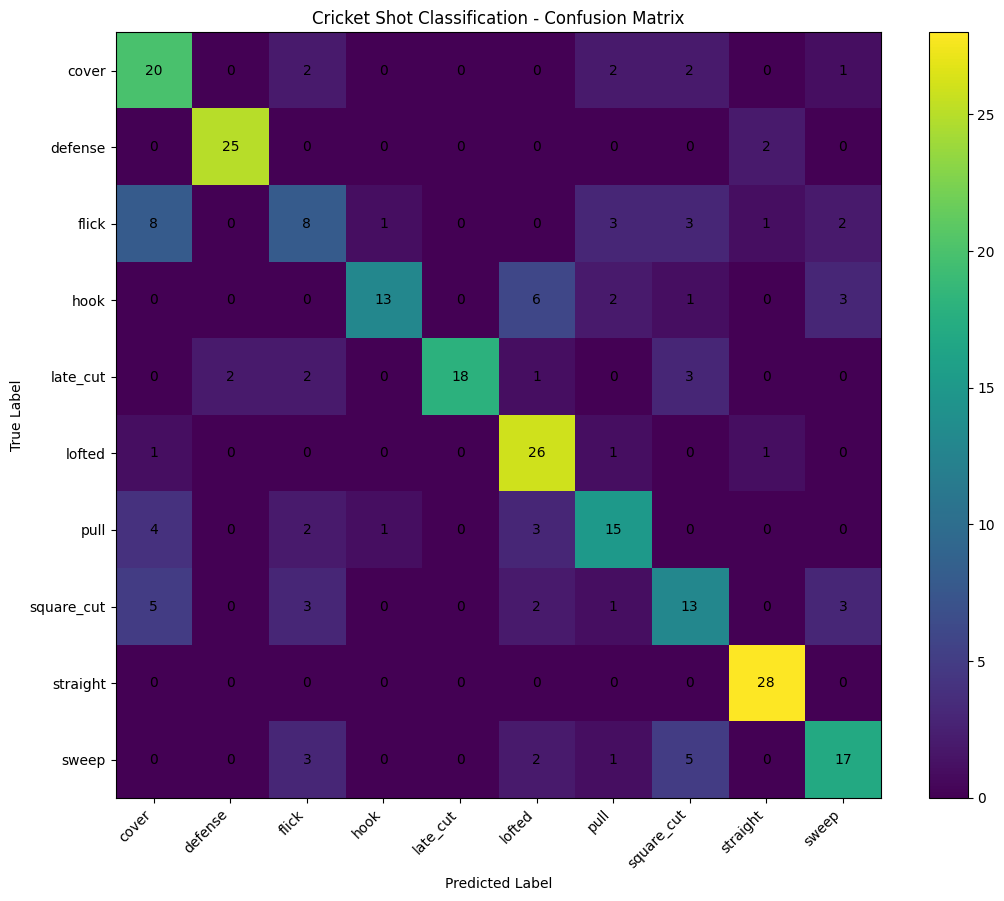


TEST EVALUATION COMPLETE ✅
Results saved to:
/content/drive/MyDrive/cricket_videomae/test_results.pt


In [ ]:
# ============================================================
# TEST EVALUATION — BEST MODEL (EPOCH 5)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("=" * 60)
print("EVALUATING BEST CRICKET VIDEOMAE MODEL")
print("=" * 60)

# ------------------------------------------------------------
# LOAD BEST CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Checkpoint loaded successfully ✅")
print("Best Epoch:", checkpoint["epoch"])
print(
    "Best Validation Accuracy:",
    f"{checkpoint['val_accuracy']:.4f}"
)
print("Device:", device)

# ------------------------------------------------------------
# TEST PREDICTIONS
# ------------------------------------------------------------

all_predictions = []
all_labels = []

print()
print("Running test evaluation...")

with torch.no_grad():

    for step, batch in enumerate(test_loader):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            pixel_values=pixel_values
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        if (step + 1) % 20 == 0:
            print(
                f"Test Batch {step + 1}/{len(test_loader)}"
            )

# ------------------------------------------------------------
# CONVERT TO NUMPY
# ------------------------------------------------------------

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# PRINT FINAL METRICS
# ------------------------------------------------------------

print()
print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(
    f"Test Accuracy : {test_accuracy:.4f}"
)

print(
    f"Test Precision: {test_precision:.4f}"
)

print(
    f"Test Recall   : {test_recall:.4f}"
)

print(
    f"Test F1-score : {test_f1:.4f}"
)

print("=" * 60)

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print()
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

# ------------------------------------------------------------
# PLOT CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(11, 9))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Cricket Shot Classification - Confusion Matrix"
)

plt.colorbar()

tick_marks = np.arange(
    len(class_names)
)

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

test_results = {
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "best_epoch": checkpoint["epoch"],
    "best_validation_accuracy":
        checkpoint["val_accuracy"],
    "predictions": all_predictions,
    "labels": all_labels,
    "confusion_matrix": cm
}

torch.save(
    test_results,
    "/content/drive/MyDrive/cricket_videomae/test_results.pt"
)

print()
print("=" * 60)
print("TEST EVALUATION COMPLETE ✅")
print("=" * 60)
print(
    "Results saved to:"
)
print(
    "/content/drive/MyDrive/cricket_videomae/test_results.pt"
)

In [ ]:
# ============================================================
# CONTINUE FROM BEST EPOCH-5 CHECKPOINT
# EPOCH 6 → EPOCH 8
# ============================================================

import time
import torch

print("=" * 60)
print("RETRAINING FROM BEST EPOCH-5 CHECKPOINT")
print("=" * 60)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CHECKPOINT_PATH = "/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt"

START_EPOCH = 6
FINAL_EPOCH = 8

# Lower learning rate to reduce overfitting
LEARNING_RATE = 1e-5

print("Starting Epoch :", START_EPOCH)
print("Final Epoch    :", FINAL_EPOCH)
print("Learning Rate  :", LEARNING_RATE)
print("Device         :", device)
print("=" * 60)


# ============================================================
# LOAD BEST EPOCH-5 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print()
print("Best checkpoint restored ✅")
print("Saved Epoch:", checkpoint["epoch"])
print(
    "Best Validation Accuracy:",
    checkpoint["val_accuracy"]
)


# ============================================================
# RESET OPTIMIZER WITH SMALLER LEARNING RATE
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

criterion = torch.nn.CrossEntropyLoss()

print()
print("Optimizer recreated ✅")
print("Learning Rate:", LEARNING_RATE)


# ============================================================
# RESTORE HISTORY
# ============================================================

history = checkpoint.get(
    "history",
    {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
)

best_val_accuracy = checkpoint["val_accuracy"]

print()
print("Current Best Validation Accuracy:",
      f"{best_val_accuracy:.4f}")


# ============================================================
# TRAIN EPOCH 6 → 8
# ============================================================

for epoch in range(START_EPOCH, FINAL_EPOCH + 1):

    print()
    print("=" * 60)
    print(f"Epoch {epoch}/{FINAL_EPOCH}")
    print("=" * 60)

    start_time = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for step, batch in enumerate(train_loader):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values
        )

        loss = criterion(
            outputs.logits,
            labels
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += loss.item()

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (step + 1) % 50 == 0:

            current_loss = (
                running_loss / (step + 1)
            )

            current_accuracy = (
                correct / total
            )

            print(
                f"Step {step + 1}/{len(train_loader)} "
                f"| Loss: {current_loss:.4f} "
                f"| Accuracy: {current_accuracy:.4f}"
            )


    # ========================================================
    # TRAIN RESULTS
    # ========================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_accuracy = (
        correct / total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader:

            pixel_values = batch[
                "pixel_values"
            ].to(device)

            labels = batch[
                "labels"
            ].to(device)

            outputs = model(
                pixel_values=pixel_values
            )

            loss = criterion(
                outputs.logits,
                labels
            )

            val_running_loss += loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    # ========================================================
    # VALIDATION RESULTS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time() - start_time
    ) / 60


    # ========================================================
    # RESULTS
    # ========================================================

    print()
    print("Epoch Results")
    print("-----------------------")

    print(
        f"Train Loss:      {train_loss:.4f}"
    )

    print(
        f"Train Accuracy:  {train_accuracy:.4f}"
    )

    print(
        f"Val Loss:        {val_loss:.4f}"
    )

    print(
        f"Val Accuracy:    {val_accuracy:.4f}"
    )

    print(
        f"Time:            {epoch_time:.2f} minutes"
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_accuracy":
                    val_accuracy,

                "label2id":
                    label2id,

                "id2label":
                    id2label,

                "class_names":
                    class_names,

                "num_frames":
                    checkpoint.get(
                        "num_frames",
                        16
                    ),

                "history":
                    history
            },
            CHECKPOINT_PATH
        )

        print()
        print("🔥 NEW BEST MODEL SAVED!")

        print(
            f"Best Epoch: {epoch}"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_accuracy:.4f}"
        )

    else:

        print()
        print(
            "No improvement. "
            f"Best validation accuracy remains "
            f"{best_val_accuracy:.4f}"
        )


# ============================================================
# COMPLETE
# ============================================================

print()
print("=" * 60)
print("RETRAINING COMPLETE")
print("=" * 60)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Best Checkpoint: "
    f"{CHECKPOINT_PATH}"
)

print("=" * 60)

RETRAINING FROM BEST EPOCH-5 CHECKPOINT
Starting Epoch : 6
Final Epoch    : 8
Learning Rate  : 1e-05
Device         : cuda

Best checkpoint restored ✅
Saved Epoch: 5
Best Validation Accuracy: 0.700374531835206

Optimizer recreated ✅
Learning Rate: 1e-05

Current Best Validation Accuracy: 0.7004

Epoch 6/8
Step 50/312 | Loss: 0.4764 | Accuracy: 0.9550
Step 100/312 | Loss: 0.4587 | Accuracy: 0.9475
Step 150/312 | Loss: 0.4672 | Accuracy: 0.9333
Step 200/312 | Loss: 0.4633 | Accuracy: 0.9300
Step 250/312 | Loss: 0.4499 | Accuracy: 0.9290
Step 300/312 | Loss: 0.4487 | Accuracy: 0.9267

Epoch Results
-----------------------
Train Loss:      0.4471
Train Accuracy:  0.9270
Val Loss:        1.0072
Val Accuracy:    0.6704
Time:            17.19 minutes

No improvement. Best validation accuracy remains 0.7004

Epoch 7/8
Step 50/312 | Loss: 0.2779 | Accuracy: 0.9650
Step 100/312 | Loss: 0.2680 | Accuracy: 0.9700
Step 150/312 | Loss: 0.2505 | Accuracy: 0.9733
Step 200/312 | Loss: 0.2439 | Accuracy

In [ ]:
# ============================================================
# GENTLE FINE-TUNING FROM BEST EPOCH-8 CHECKPOINT
# EPOCH 9 → EPOCH 11
# ============================================================

import time
import torch

print("=" * 60)
print("GENTLE FINETUNING CRICKET VIDEOMAE")
print("=" * 60)

CHECKPOINT_PATH = (
    "/content/drive/MyDrive/cricket_videomae/"
    "best_cricket_videomae.pt"
)

START_EPOCH = 9
FINAL_EPOCH = 11

# Smaller learning rate
LEARNING_RATE = 5e-6

print("Starting Epoch :", START_EPOCH)
print("Final Epoch    :", FINAL_EPOCH)
print("Learning Rate  :", LEARNING_RATE)
print("Device         :", device)
print("=" * 60)


# ============================================================
# LOAD CURRENT BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_val_accuracy = checkpoint["val_accuracy"]

history = checkpoint.get(
    "history",
    {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }
)

print()
print("Checkpoint restored ✅")
print("Saved Epoch:", checkpoint["epoch"])
print(
    "Best Validation Accuracy:",
    f"{best_val_accuracy:.4f}"
)


# ============================================================
# NEW LOW LEARNING-RATE OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.02
)

criterion = torch.nn.CrossEntropyLoss()

print()
print("Optimizer recreated ✅")
print("Learning Rate:", LEARNING_RATE)
print("Weight Decay :", 0.02)


# ============================================================
# EPOCH 9 → 11
# ============================================================

for epoch in range(START_EPOCH, FINAL_EPOCH + 1):

    print()
    print("=" * 60)
    print(f"Epoch {epoch}/{FINAL_EPOCH}")
    print("=" * 60)

    start_time = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for step, batch in enumerate(train_loader):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values
        )

        loss = criterion(
            outputs.logits,
            labels
        )

        loss.backward()

        # Prevent unstable large gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += loss.item()

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (step + 1) % 50 == 0:

            current_loss = (
                running_loss / (step + 1)
            )

            current_accuracy = (
                correct / total
            )

            print(
                f"Step {step + 1}/{len(train_loader)} "
                f"| Loss: {current_loss:.4f} "
                f"| Accuracy: {current_accuracy:.4f}"
            )


    # ========================================================
    # TRAIN RESULTS
    # ========================================================

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_accuracy = (
        correct /
        total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader:

            pixel_values = batch[
                "pixel_values"
            ].to(device)

            labels = batch[
                "labels"
            ].to(device)

            outputs = model(
                pixel_values=pixel_values
            )

            loss = criterion(
                outputs.logits,
                labels
            )

            val_running_loss += loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    # ========================================================
    # VALIDATION RESULTS
    # ========================================================

    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time() - start_time
    ) / 60


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print()
    print("Epoch Results")
    print("-----------------------")

    print(
        f"Train Loss:      {train_loss:.4f}"
    )

    print(
        f"Train Accuracy:  {train_accuracy:.4f}"
    )

    print(
        f"Val Loss:        {val_loss:.4f}"
    )

    print(
        f"Val Accuracy:    {val_accuracy:.4f}"
    )

    print(
        f"Time:            {epoch_time:.2f} minutes"
    )


    # ========================================================
    # UPDATE HISTORY
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_accuracy
    )


    # ========================================================
    # SAVE ONLY IF VALIDATION IMPROVES
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_accuracy":
                    val_accuracy,

                "label2id":
                    label2id,

                "id2label":
                    id2label,

                "class_names":
                    class_names,

                "num_frames":
                    checkpoint.get(
                        "num_frames",
                        16
                    ),

                "history":
                    history
            },
            CHECKPOINT_PATH
        )

        print()
        print("🔥 NEW BEST MODEL SAVED!")

        print(
            f"Best Epoch: {epoch}"
        )

        print(
            f"Best Validation Accuracy: "
            f"{best_val_accuracy:.4f}"
        )

    else:

        print()
        print(
            "No improvement. "
            f"Best validation accuracy remains "
            f"{best_val_accuracy:.4f}"
        )


# ============================================================
# COMPLETE
# ============================================================

print()
print("=" * 60)
print("GENTLE FINE-TUNING COMPLETE")
print("=" * 60)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Best Checkpoint: "
    f"{CHECKPOINT_PATH}"
)

print("=" * 60)

GENTLE FINETUNING CRICKET VIDEOMAE
Starting Epoch : 9
Final Epoch    : 11
Learning Rate  : 5e-06
Device         : cuda

Checkpoint restored ✅
Saved Epoch: 8
Best Validation Accuracy: 0.7079

Optimizer recreated ✅
Learning Rate: 5e-06
Weight Decay : 0.02

Epoch 9/11
Step 50/312 | Loss: 0.0610 | Accuracy: 1.0000
Step 100/312 | Loss: 0.0627 | Accuracy: 0.9975
Step 150/312 | Loss: 0.0586 | Accuracy: 0.9983
Step 200/312 | Loss: 0.0581 | Accuracy: 0.9975
Step 250/312 | Loss: 0.0552 | Accuracy: 0.9980
Step 300/312 | Loss: 0.0530 | Accuracy: 0.9983

Epoch Results
-----------------------
Train Loss:      0.0555
Train Accuracy:  0.9976
Val Loss:        0.9563
Val Accuracy:    0.7154
Time:            17.01 minutes

🔥 NEW BEST MODEL SAVED!
Best Epoch: 9
Best Validation Accuracy: 0.7154

Epoch 10/11
Step 50/312 | Loss: 0.0405 | Accuracy: 1.0000
Step 100/312 | Loss: 0.0416 | Accuracy: 0.9975
Step 150/312 | Loss: 0.0386 | Accuracy: 0.9983
Step 200/312 | Loss: 0.0362 | Accuracy: 0.9988
Step 250/312 | 

In [ ]:
# ============================================================
# GENTLE FINETUNING FROM BEST EPOCH-10 CHECKPOINT
# EPOCH 11 → EPOCH 12
# ============================================================

import torch
import time

START_EPOCH = 11
FINAL_EPOCH = 12

# Keep learning rate VERY LOW
LEARNING_RATE = 2e-6

print("=" * 60)
print("GENTLE FINETUNING CRICKET VIDEOMAE")
print("=" * 60)
print(f"Starting Epoch : {START_EPOCH}")
print(f"Final Epoch    : {FINAL_EPOCH}")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Device         : {device}")
print("=" * 60)


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best checkpoint restored ✅")
print("Saved Epoch:", checkpoint["epoch"])
print("Best Validation Accuracy:",
      checkpoint["val_accuracy"])


# ============================================================
# RECREATE OPTIMIZER WITH LOWER LR
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.02
)

print()
print("Optimizer recreated ✅")
print("Learning Rate:", LEARNING_RATE)
print("Weight Decay: 0.02")


best_val_accuracy = checkpoint["val_accuracy"]

print()
print(f"Current Best Validation Accuracy: "
      f"{best_val_accuracy:.4f}")


# ============================================================
# TRAINING
# ============================================================

for epoch in range(START_EPOCH, FINAL_EPOCH + 1):

    print()
    print("=" * 60)
    print(f"Epoch {epoch}/{FINAL_EPOCH}")
    print("=" * 60)

    start_time = time.time()

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for step, batch in enumerate(train_loader):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            pixel_values=pixel_values
        )

        loss = criterion(
            outputs.logits,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        if (step + 1) % 50 == 0:

            print(
                f"Step {step + 1}/{len(train_loader)} "
                f"| Loss: "
                f"{running_loss / (step + 1):.4f} "
                f"| Accuracy: "
                f"{correct / total:.4f}"
            )


    # ========================================================
    # TRAIN RESULTS
    # ========================================================

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader:

            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                pixel_values=pixel_values
            )

            loss = criterion(
                outputs.logits,
                labels
            )

            val_running_loss += loss.item()

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)


    val_loss = val_running_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    epoch_time = (time.time() - start_time) / 60


    # ========================================================
    # RESULTS
    # ========================================================

    print()
    print("Epoch Results")
    print("-----------------------")

    print(f"Train Loss:      {train_loss:.4f}")
    print(f"Train Accuracy:  {train_accuracy:.4f}")
    print(f"Val Loss:        {val_loss:.4f}")
    print(f"Val Accuracy:    {val_accuracy:.4f}")
    print(f"Time:            {epoch_time:.2f} minutes")


    # ========================================================
    # SAVE ONLY IF BETTER
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
                "label2id": label2id,
                "id2label": id2label,
                "class_names": class_names,
                "num_frames": checkpoint.get(
                    "num_frames",
                    16
                ),
                "history": history
            },
            CHECKPOINT_PATH
        )

        print()
        print("🔥 NEW BEST MODEL SAVED!")
        print(f"Best Epoch: {epoch}")
        print(
            f"Best Validation Accuracy: "
            f"{best_val_accuracy:.4f}"
        )

    else:

        print()
        print(
            f"No improvement. "
            f"Best validation accuracy remains "
            f"{best_val_accuracy:.4f}"
        )


print()
print("=" * 60)
print("GENTLE FINETUNING COMPLETE")
print("=" * 60)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(f"Best Checkpoint: {CHECKPOINT_PATH}")
print("=" * 60)

GENTLE FINETUNING CRICKET VIDEOMAE
Starting Epoch : 11
Final Epoch    : 12
Learning Rate  : 2e-06
Device         : cuda
Best checkpoint restored ✅
Saved Epoch: 10
Best Validation Accuracy: 0.7303370786516854

Optimizer recreated ✅
Learning Rate: 2e-06
Weight Decay: 0.02

Current Best Validation Accuracy: 0.7303

Epoch 11/12
Step 50/312 | Loss: 0.0258 | Accuracy: 1.0000
Step 100/312 | Loss: 0.0287 | Accuracy: 1.0000
Step 150/312 | Loss: 0.0275 | Accuracy: 1.0000
Step 200/312 | Loss: 0.0266 | Accuracy: 1.0000
Step 250/312 | Loss: 0.0262 | Accuracy: 1.0000
Step 300/312 | Loss: 0.0258 | Accuracy: 1.0000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

CHECKPOINT_PATH = "/content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt"

print("Exists:", os.path.exists(CHECKPOINT_PATH))
print("Path:", CHECKPOINT_PATH)

if os.path.exists(CHECKPOINT_PATH):
    print("Size:", os.path.getsize(CHECKPOINT_PATH) / (1024**2), "MB")

Exists: True
Path: /content/drive/MyDrive/cricket_videomae/best_cricket_videomae.pt
Size: 250.7413206100464 MB


In [ ]:
from google.colab import files

files.download(CHECKPOINT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>